In [1]:
#    Define input file for BOUT++

import numpy as np
import scipy
import xbout
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import os
import sympy as sp
from scipy.optimize import curve_fit
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 200  
plt.ioff()
#%load_ext autoreload
#%autoreload 2
params = {'legend.fontsize': 8,
'legend.title_fontsize': 8,
'figure.figsize': (4.8, 4.8),
'axes.labelsize': 12,
'axes.titlesize': 15,
'xtick.labelsize':8,
'ytick.labelsize':8,
'font.family': 'serif',
'text.usetex': False}
plt.rcParams.update(params)


analyze=True
analyzemode="single"
def create_directory(path):
    """Creates a directory if it does not already exist."""
    os.makedirs(path, exist_ok=True)
    print(f"Directory '{path}' is ready.")


def calc_vmin_vmax(ar,cut, equalize=True):
    tmp1=np.percentile(ar,cut)
    tmp2=np.percentile(ar,100-cut)
    if np.sign(tmp1) != np.sign(tmp2) and equalize==True:
        return -np.max((abs(tmp1),abs(tmp2))),np.max((abs(tmp1),abs(tmp2)))
    else:
        return tmp1,tmp2

def write_BOUT_inp(inputobj,SSDir,gridfile,nx):
    # Normalization, beacuse x does indeed not go from 0 to 1, this screws up
    # the calculation for the perp derivatives
    
    
    minvalue=(-2.0+0.5) / (nx - 2*2)
    maxvalue=(nx-3+0.5) / (nx - 2*2)
    xmin=0
    xmax=1
    
    cont = f"""
#

repetitions=1
nout = 30*repetitions
timestep = repetitions*{inputobj.AUX["Omegadenom"]}/nout

grid = "{gridfile}"

#xl= ({np.round(xmax-xmin,2)})*(x-({np.round(minvalue,8)}))/(({np.round(maxvalue,8)})-({np.round(minvalue,8)})) + ({np.round(xmin,2)})
xl=x
zl = z/(2.0*pi)
yl = y
[mesh]
symmetricGlobalX = true

extrapolate_y = false   # Extrapolate metrics into Y boundary cells?

[mesh:paralleltransform]
type = fci

[input]
error_on_unused_options=false

[restart_files]
init_missing = true # initialize missing variables on restart?


########################################################################################


# derivative methods

[mesh:ddx]

first = C2
second = C2
upwind = W3

[mesh:ddy]

first = C2
second = C2
upwind = W3

[mesh:ddz]

first = C2
second = C2
upwind = W3


########################################################################################


[mesh:paralleltransform:xzinterpolation]
type = hermitespline
#type = monotonichermitespline



###################################################


[solver]


# Note: If evolving neutrals, need preconditioning
type = pvode
atol = 1.0e-10  # absolute tolerance
rtol = 1.0e-6   # relative tolerance
mxstep = 8000  # Maximum internal steps per output
mms = true
mms_initialise = true
cvode_max_order = 3
use_precon = false

########################################################################################


[phiSolver]

type   = petsc  # Needed if Boussinesq = false

ksptype = gmres # Linear iterative method

pctype = hypre # Preconditioner. Direct "lu" or "ilu"; iterative "jacobi", "sor"

atol=1e-8
rtol = 1e-5
# Set package to perform factorisation for direct solves
# "petsc" built-in solver only serial
# "superlu", "superlu_dist", "mumps", "cusparse"
factor_package = superlu_dist

inner_boundary_flags = 16
outer_boundary_flags = 16

all_terms = true
nonuniform = true   # NOTE: Necessary to avoid numerical instability


#########################################################################################


[aparSolver]
type = petsc

rtol=1e-5
atol=1e-10

ksptype = gmres   # Linear iterative method

pctype  = hypre   # Preconditioner. Direct "lu" or "ilu"; iterative "jacobi", "sor"

# # Set package to perform factorisation for direct solves
# # "petsc" built-in solver only serial
# # "superlu", "superlu_dist", "mumps", "cusparse"
factor_package = superlu_dist


inner_boundary_flags = 0
outer_boundary_flags = 0

all_terms = false
nonuniform = true


#########################################################################################


[preconSolver]
type = petsc
rtol=1e-5
atol=1e-8
ksptype = gmres   # Linear iterative method
pctype  = hypre   # Preconditioner. Direct "lu" or "ilu"; iterative "jacobi", "sor"
factor_package = superlu_dist
inner_boundary_flags = 2
outer_boundary_flags = 2
all_terms = true
nonuniform = true

# general settings for the model
[input]

transform_from_field_aligned=False


########################################################################################


[Hermes]

electromagnetic = {inputobj.AUX["electromagnetic"]}
j_pol_pi = {inpobj.AUX["j_pol_pi"]}
j_pol_simplified = true
boussinesq = true
FiniteElMass = true
calc_potential = {inpobj.AUX["calc_potential"]}

evolve_ne = {inputobj.Ne["evolve_ne"]}
evolve_nvi = {inputobj.NVi["evolve_nvi"]}
evolve_te = {inputobj.Pe["evolve_pe"]}
evolve_ti = {inputobj.Pi["evolve_pi"]}

evolve_vort = {inputobj.Vort["evolve_vort"]}
evolve_vepsi = {inputobj.VePsi["evolve_vepsi"]}


TE_Ne = true
TE_NVi = true
TE_Pe = true
TE_Pi = true
TE_Vort = true
TE_VePsi = true
verbose = true
output_ddt = true



Tnorm = 20
Nnorm = 1e19
Bnorm = 1.0
AA = 2.0


########################################################################################


[Transportcoefficients]

anomalous_D = {inputobj.Transportcoefficients["anomalous_D"]}
anomalous_nu = {inputobj.Transportcoefficients["anomalous_nu"]}
anomalous_chi = {inputobj.Transportcoefficients["anomalous_chi"]}



hyper_D = {inputobj.Transportcoefficients["hyper_D"]}
hyper_nu = {inputobj.Transportcoefficients["hyper_nu"]}
hyper_chi = {inputobj.Transportcoefficients["hyper_chi"]}


num_D = {inputobj.Transportcoefficients["num_D"]}
num_nu = {inputobj.Transportcoefficients["num_nu"]}
num_chi = {inputobj.Transportcoefficients["num_chi"]}


########################################################################################


[Numerics]


use_Div_n_bxGrad_f_B_XPPM = false
use_bracket = true
use_new_conduction = true
use_new_viscosity = false

use_new_div_par = false
use_slope_limiter = false

use_new_grad_par = false

use_Delp2 = false
use_new_divagradperp = false

check_finite = false

ne_bndry_flux = true
pe_bndry_flux = true
vort_bndry_flux = true

flux_limit_alpha = -1
kappa_limit_alpha = -0.3
eta_limit_alpha = -0.5


floor_Ne = 0.05
floor_Te = 1.0/20.0
floor_Ti = 1.0/20.0

resistivity_multiply = {inpobj.AUX["resistivity_multiply"]}

anomalous_precon = true

########################################################################################


[Sheath]

sheath_model = 0
par_sheath_model = 0
sheath_gamma_e = 5.0
sheath_gamma_i = 3.5

parallel_sheaths = false
sheath_allow_supersonic = true
sheath_infsink = false
infsink_Te = 0.5


########################################################################################
########################################################################################
########################################################################################


[all]


bndry_par_all = parallel_neumann_o1


########################################################################################


[Ne] # Electron density

bndry_xin = dirichlet_o2(Ne:solution)
bndry_xout = dirichlet_o2(Ne:solution)
bndry_par = parallel_neumann_o2


solution={SSDir.solutions["Ne"]}
source={SSDir.sources["Ne"]}


use_Vi = true

Ne_ExB = {inputobj.Ne["Ne_ExB"]}
Ne_mag = {inputobj.Ne["Ne_mag"]}
Ne_parflow = {inputobj.Ne["Ne_parflow"]}
Ne_collision = {inputobj.Ne["Ne_collision"]}
Ne_anomalous = {inputobj.Ne["Ne_anomalous"]}
Ne_sources = {inputobj.Ne["Ne_sources"]}
Ne_hyper = {inputobj.Ne["Ne_hyper"]}
Ne_numdiff = {inputobj.Ne["Ne_numdiff"]}


########################################################################################


[NVi]

bndry_xin = dirichlet_o2(NVi:solution)
bndry_xout = dirichlet_o2(NVi:solution)

solution={SSDir.solutions["NVi"]}
source={SSDir.sources["NVi"]}

NVi_ExB = {inputobj.NVi["NVi_ExB"]}
NVi_mag = {inputobj.NVi["NVi_mag"]}
NVi_parflow = {inputobj.NVi["NVi_parflow"]}
NVi_parpressure = {inputobj.NVi["NVi_parpressure"]}
NVi_parviscos = {inputobj.NVi["NVi_parviscos"]}
NVi_collision = {inputobj.NVi["NVi_collision"]}
NVi_anomalous = {inputobj.NVi["NVi_anomalous"]}
NVi_hyper = {inputobj.NVi["NVi_hyper"]}
NVi_numdiff = {inputobj.NVi["NVi_numdiff"]}
NVi_supsonicdampening = {inputobj.NVi["NVi_supsonicdampening"]}


########################################################################################


[Pe]  # Electron pressure

bndry_xin = dirichlet_o2(Pe:solution)
bndry_xout = dirichlet_o2(Pe:solution)

solution={SSDir.solutions["Pe"]}
source={SSDir.sources["Pe"]}

Pe_ExB = {inputobj.Pe["Pe_ExB"]}
Pe_mag = {inputobj.Pe["Pe_mag"]}
Pe_parflow = {inputobj.Pe["Pe_parflow"]}
Pe_conduction = {inputobj.Pe["Pe_conduction"]}
Pe_ohmic = {inputobj.Pe["Pe_ohmic"]}
Pe_thermalforce = {inputobj.Pe["Pe_thermalforce"]}
Pe_thermalcurrent = {inputobj.Pe["Pe_thermalcurrent"]}
Pe_collision = {inputobj.Pe["Pe_collision"]}
Pe_anomalous = {inputobj.Pe["Pe_anomalous"]}
Pe_sources = {inputobj.Pe["Pe_sources"]}
Pe_energyexchange = {inputobj.Pe["Pe_energyexchange"]}
Pe_hyper = {inputobj.Pe["Pe_hyper"]}
Pe_numdiff = {inputobj.Pe["Pe_numdiff"]}
Pe_dampening = {inputobj.Pe["Pe_dampening"]}


########################################################################################


[Pi]

bndry_xin = dirichlet_o2(Pi:solution)
bndry_xout = dirichlet_o2(Pi:solution)

solution={SSDir.solutions["Pi"]}
source={SSDir.sources["Pi"]}

Pi_ExB = {inputobj.Pi["Pi_ExB"]}
Pi_mag = {inputobj.Pi["Pi_mag"]}
Pi_parflow = {inputobj.Pi["Pi_parflow"]}
Pi_conduction = {inputobj.Pi["Pi_conduction"]}
Pi_diamagenergyexchange = {inputobj.Pi["Pi_diamagenergyexchange"]}
Pi_parviscousheat = {inputobj.Pi["Pi_parviscousheat"]}
Pi_resistivedrift = {inputobj.Pi["Pi_resistivedrift"]}
Pi_perpviscous = {inputobj.Pi["Pi_perpviscous"]}
Pi_sources = {inputobj.Pi["Pi_sources"]}
Pi_hyper = {inputobj.Pi["Pi_hyper"]}
Pi_numdiff = {inputobj.Pi["Pi_numdiff"]}
Pi_anomalous = {inputobj.Pi["Pi_anomalous"]}
Pi_energyexchange = {inputobj.Pi["Pi_energyexchange"]}


########################################################################################


[Vort]

bndry_xin = dirichlet_o2(Vort:solution)
bndry_xout = dirichlet_o2(Vort:solution)

solution={SSDir.solutions["Vort"]}
source={SSDir.sources["Vort"]}

Vort_mag = {inputobj.Vort["Vort_mag"]}
Vort_parcurrent = {inputobj.Vort["Vort_parcurrent"]}
Vort_polarcurrent = {inputobj.Vort["Vort_polarcurrent"]}
Vort_collision = {inputobj.Vort["Vort_collision"]}
Vort_parviscous = {inputobj.Vort["Vort_parviscous"]}
Vort_anomalous = {inputobj.Vort["Vort_anomalous"]}
Vort_hyper = {inputobj.Vort["Vort_hyper"]}
Vort_numdiff = {inputobj.Vort["Vort_numdiff"]}
Vort_parflow = {inputobj.Vort["Vort_parflow"]}


########################################################################################


[VePsi] 

bndry_xin = dirichlet_o2(VePsi:solution)
bndry_xout = dirichlet_o2(VePsi:solution)

solution={SSDir.solutions["VePsi"]}
source={SSDir.sources["VePsi"]}

VePsi_parefield = {inputobj.VePsi["VePsi_parefield"]}
VePsi_parpressure = {inputobj.VePsi["VePsi_parpressure"]}
VePsi_partemp = {inputobj.VePsi["VePsi_partemp"]}
VePsi_parcurrent = {inputobj.VePsi["VePsi_parcurrent"]}
VePsi_ExB = {inputobj.VePsi["VePsi_ExB"]}
VePsi_parflow = {inputobj.VePsi["VePsi_parflow"]}
VePsi_hyper = {inputobj.VePsi["VePsi_hyper"]}
VePsi_numdiff = {inputobj.VePsi["VePsi_numdiff"]}
VePsi_parallelvisc = {inputobj.VePsi["VePsi_parallelvisc"]}
VePsi_supsonicdampening = {inputobj.VePsi["VePsi_supsonicdampening"]}
VePsi_anomalous = {inputobj.VePsi["VePsi_anomalous"]}





    """
    return cont

def write_slurmfile(id,nodes,ntasks_per_node, mem,time_h,time_min,
                   executable,directory,name):
    content=f"""#!/bin/bash -l                                                                                                                                        
# Standard output and error:                                                                                                                          
#SBATCH -o {directory}/job_hybrid.out.%j                                                                                                                        
#SBATCH -e {directory}/job_hybrid.err.%j                                                                                                                        
# Initial working directory:                                                                                                                          
#SBATCH -D {directory}                                                                                                                                         
# Job Name:                                                                                                                                           
#SBATCH -J MMS_Braginskii_{name}_{int(id)}                                                                                                                         
#                                                                                                                                                     
# Number of nodes and MPI tasks per node:                                                                                                             
#SBATCH --nodes={nodes}                                                                                                                                    
#SBATCH --ntasks-per-node={int(ntasks_per_node)}                                                                                                                          
#SBATCH --mem={int(mem)}GB                                                                                                                                    

# for OpenMP:                                                                                                                                         
#SBATCH --cpus-per-task=1                                                                                                                             
#SBATCH --mail-type=all                                                                                                                               
#SBATCH --mail-user=toto@ipp.mpg.de                                                                                                                   
#                                                                                                                                                     
# Wall clock limit (max. is 24 hours):                                                                                                                
#SBATCH --time={int(time_h)}:{int(time_min)}:00                                                                                                                               
set -x
# Load compiler and MPI modules (must be the same as used for compiling the code)                                                                     
module purge
module load gcc/13 openmpi/4.1 hdf5-serial/1.14.1 netcdf-serial/4.9.2 fftw-mpi/3.3.10 anaconda/3/2021.11 mkl/2024.0

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# For pinning threads correctly:                                                                                                                      
export OMP_PLACES=cores

# Run the program                                                                                                                                     

srun {executable} -d {directory} $@
    
    """
    return content


def gridfile_string(nx,ny,nz,directory):
    content = f"{directory}/cor_MMS_straight_slab_{nx}_{ny}_{nz}.fci.grid.nc"
    return content

def read_solution_source(var):
    with open(f"solution_{var}.txt", "r") as file:
        solution = file.read()
        
    with open(f"source_{var}.txt", "r") as file:
        source = file.read()
    
    return solution,source


class Input_class():
    def __init__(self):
        self.Vort={}
        self.Ne={}
        self.NVi={}
        self.Pe={}
        self.Pi={}
        self.VePsi={}
        self.Transportcoefficients={}
        self.AUX={}
    def set_AUX(self,Omegadenom, resistivity_multiply,electromagnetic,presetmode,
               j_pol_pi, calc_potential):
        self.AUX["Omegadenom"] = Omegadenom
        self.AUX["resistivity_multiply"] = resistivity_multiply
        self.AUX["electromagnetic"] = electromagnetic
        self.AUX["presetmode"] = presetmode
        self.AUX["j_pol_pi"] = j_pol_pi
        self.AUX["calc_potential"]=calc_potential
    
    def set_Vort(self,evolve_vort , Vort_mag , Vort_parcurrent , Vort_polarcurrent , Vort_collision , Vort_parviscous , 
                Vort_anomalous , Vort_hyper , Vort_numdiff , Vort_parflow):
        self.Vort["evolve_vort"]=evolve_vort
        self.Vort["Vort_mag"]=Vort_mag
        self.Vort["Vort_parcurrent"]=Vort_parcurrent
        self.Vort["Vort_polarcurrent"]=Vort_polarcurrent
        self.Vort["Vort_collision"]=Vort_collision
        self.Vort["Vort_parviscous"]=Vort_parviscous
        self.Vort["Vort_anomalous"]=Vort_anomalous
        self.Vort["Vort_hyper"]=Vort_hyper
        self.Vort["Vort_numdiff"]=Vort_numdiff
        self.Vort["Vort_parflow"]=Vort_parflow
        
    def set_VePsi(self, evolve_vepsi, VePsi_parefield, VePsi_parpressure, VePsi_partemp, VePsi_parcurrent, VePsi_ExB, 
              VePsi_parflow, VePsi_hyper, VePsi_numdiff, VePsi_parallelvisc, VePsi_supsonicdampening, 
              VePsi_anomalous):
        self.VePsi["evolve_vepsi"] = evolve_vepsi
        self.VePsi["VePsi_parefield"] = VePsi_parefield
        self.VePsi["VePsi_parpressure"] = VePsi_parpressure
        self.VePsi["VePsi_partemp"] = VePsi_partemp
        self.VePsi["VePsi_parcurrent"] = VePsi_parcurrent
        self.VePsi["VePsi_ExB"] = VePsi_ExB
        self.VePsi["VePsi_parflow"] = VePsi_parflow
        self.VePsi["VePsi_hyper"] = VePsi_hyper
        self.VePsi["VePsi_numdiff"] = VePsi_numdiff
        self.VePsi["VePsi_parallelvisc"] = VePsi_parallelvisc
        self.VePsi["VePsi_supsonicdampening"] = VePsi_supsonicdampening
        self.VePsi["VePsi_anomalous"] = VePsi_anomalous
    
    def set_Pi(self, evolve_pi, Pi_ExB, Pi_mag, Pi_parflow, Pi_conduction, Pi_diamagenergyexchange, 
           Pi_parviscousheat, Pi_resistivedrift, Pi_perpviscous, Pi_sources, Pi_hyper, Pi_numdiff, 
           Pi_anomalous, Pi_energyexchange):
        self.Pi["evolve_pi"] = evolve_pi
        self.Pi["Pi_ExB"] = Pi_ExB
        self.Pi["Pi_mag"] = Pi_mag
        self.Pi["Pi_parflow"] = Pi_parflow
        self.Pi["Pi_conduction"] = Pi_conduction
        self.Pi["Pi_diamagenergyexchange"] = Pi_diamagenergyexchange
        self.Pi["Pi_parviscousheat"] = Pi_parviscousheat
        self.Pi["Pi_resistivedrift"] = Pi_resistivedrift
        self.Pi["Pi_perpviscous"] = Pi_perpviscous
        self.Pi["Pi_sources"] = Pi_sources
        self.Pi["Pi_hyper"] = Pi_hyper
        self.Pi["Pi_numdiff"] = Pi_numdiff
        self.Pi["Pi_anomalous"] = Pi_anomalous
        self.Pi["Pi_energyexchange"] = Pi_energyexchange


    def set_Pe(self, evolve_pe, Pe_ExB, Pe_mag, Pe_parflow, Pe_conduction, Pe_ohmic, Pe_thermalforce, 
           Pe_thermalcurrent, Pe_collision, Pe_anomalous, Pe_sources, Pe_energyexchange, Pe_hyper, 
           Pe_numdiff, Pe_dampening):
        self.Pe["evolve_pe"] = evolve_pe
        self.Pe["Pe_ExB"] = Pe_ExB
        self.Pe["Pe_mag"] = Pe_mag
        self.Pe["Pe_parflow"] = Pe_parflow
        self.Pe["Pe_conduction"] = Pe_conduction
        self.Pe["Pe_ohmic"] = Pe_ohmic
        self.Pe["Pe_thermalforce"] = Pe_thermalforce
        self.Pe["Pe_thermalcurrent"] = Pe_thermalcurrent
        self.Pe["Pe_collision"] = Pe_collision
        self.Pe["Pe_anomalous"] = Pe_anomalous
        self.Pe["Pe_sources"] = Pe_sources
        self.Pe["Pe_energyexchange"] = Pe_energyexchange
        self.Pe["Pe_hyper"] = Pe_hyper
        self.Pe["Pe_numdiff"] = Pe_numdiff
        self.Pe["Pe_dampening"] = Pe_dampening

    def set_NVi(self, evolve_nvi, NVi_ExB, NVi_mag, NVi_parflow, NVi_parpressure, NVi_parviscos, NVi_collision, 
            NVi_anomalous, NVi_hyper, NVi_numdiff, NVi_supsonicdampening):
        self.NVi["evolve_nvi"] = evolve_nvi
        self.NVi["NVi_ExB"] = NVi_ExB
        self.NVi["NVi_mag"] = NVi_mag
        self.NVi["NVi_parflow"] = NVi_parflow
        self.NVi["NVi_parpressure"] = NVi_parpressure
        self.NVi["NVi_parviscos"] = NVi_parviscos
        self.NVi["NVi_collision"] = NVi_collision
        self.NVi["NVi_anomalous"] = NVi_anomalous
        self.NVi["NVi_hyper"] = NVi_hyper
        self.NVi["NVi_numdiff"] = NVi_numdiff
        self.NVi["NVi_supsonicdampening"] = NVi_supsonicdampening
        
    
    def set_Ne(self, evolve_ne, Ne_ExB, Ne_mag, Ne_parflow, Ne_collision, Ne_anomalous, Ne_sources, Ne_hyper, Ne_numdiff):
        self.Ne["evolve_ne"] = evolve_ne
        self.Ne["Ne_ExB"] = Ne_ExB
        self.Ne["Ne_mag"] = Ne_mag
        self.Ne["Ne_parflow"] = Ne_parflow
        self.Ne["Ne_collision"] = Ne_collision
        self.Ne["Ne_anomalous"] = Ne_anomalous
        self.Ne["Ne_sources"] = Ne_sources
        self.Ne["Ne_hyper"] = Ne_hyper
        self.Ne["Ne_numdiff"] = Ne_numdiff

    def set_Transportcoefficients(self,anomalous_D,anomalous_nu,anomalous_chi,
                                  hyper_D,hyper_nu,hyper_chi,
                                  num_D,num_nu,num_chi):
        self.Transportcoefficients["anomalous_D"]=anomalous_D
        self.Transportcoefficients["anomalous_nu"]=anomalous_nu
        self.Transportcoefficients["anomalous_chi"]=anomalous_chi
        self.Transportcoefficients["hyper_D"]=hyper_D
        self.Transportcoefficients["hyper_nu"]=hyper_nu
        self.Transportcoefficients["hyper_chi"]=hyper_chi
        self.Transportcoefficients["num_D"]=num_D
        self.Transportcoefficients["num_nu"]=num_nu
        self.Transportcoefficients["num_chi"]=num_chi
        
        
def read_solution_source(var):
    with open(f"solution_{var}.txt", "r") as file:
        solution = file.read()
        
    with open(f"source_{var}.txt", "r") as file:
        source = file.read()
    
    return solution,source    

class SolutionSinkDir():
    def __init__(self,Vars):
        self.solutions={}
        self.sources={}
        for Var in Vars:
            a, b = read_solution_source(Var)
            self.solutions[Var] = a
            self.sources[Var]= b
    
        
maindir="/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii"
        


In [2]:
inpobj=Input_class()
inpobj.set_Ne(True,False,False,False,False,False,False,False,False)#8
inpobj.set_Pe(True,False,False,False,False,False,False,False,False,False,False,False,False,False,False)#14
inpobj.set_Pi(True,False,False,False,False,False,False,False,False,False,False,False,False,False)
inpobj.set_NVi(True,False,False,False,False,False,False,False,False,False,False)#10
inpobj.set_Vort(True,False,False,False,False,False,False,False,False,False)#9
inpobj.set_VePsi(True,False,False,False,False,False,False,False,False,False,False,False)#11
inpobj.set_Transportcoefficients(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
inpobj.set_AUX(100000.0,1.0,"false","None", "false", "false")

SSobj=SolutionSinkDir(["Ne","NVi","Pe","Pi","Pe","Vort","VePsi"])



In [3]:
print("------------------------------ ")
print("--- Transport coefficients  ---")
print("------------------------------ ")


file_path = maindir+"/Transportcoefficients.json"
with open(file_path, "r") as file:
    data_TC = json.load(file)

for var in inpobj.Transportcoefficients:
    if var in data_TC:
        inpobj.Transportcoefficients[var]=data_TC[var]
        print(f"FOUND: {var} -> {data_TC[var]}")
    else:
        print(f"MISSING: {var} -> set to DEFAULT")
        

print("------------------------------ ")
print("---------  Auxiliary --------- ")
print("------------------------------ ")

file_path = maindir+"/AUX.json"
with open(file_path, "r") as file:
    data_AUX = json.load(file)

for var in inpobj.AUX:
    if var in data_AUX:
        inpobj.AUX[var]=data_AUX[var]
        print(f"FOUND: {var} -> {data_AUX[var]}")
    else:
        print(f"MISSING: {var} -> set to DEFAULT")

------------------------------ 
--- Transport coefficients  ---
------------------------------ 
FOUND: anomalous_D -> 50
FOUND: anomalous_nu -> 30
FOUND: anomalous_chi -> 35
FOUND: hyper_D -> 0.04
FOUND: hyper_nu -> 0.1
FOUND: hyper_chi -> 0.0075
FOUND: num_D -> 10000
FOUND: num_nu -> 90000
FOUND: num_chi -> 4500.0
------------------------------ 
---------  Auxiliary --------- 
------------------------------ 
FOUND: Omegadenom -> 10000.0
FOUND: resistivity_multiply -> 1.0
FOUND: electromagnetic -> false
FOUND: presetmode -> single
FOUND: j_pol_pi -> false
FOUND: calc_potential -> false


In [4]:
# LOAD ALL THE SWITCHES FROM MATHEMATICA
#Density
used_components=[]
print("------------------------------ ")
print("---------  Density   --------- ")
print("------------------------------ ")

file_path = maindir+"/SWNe.json"
with open(file_path, "r") as file:
    data_SWNe = json.load(file)

for var in inpobj.Ne:
    if var in data_SWNe:
        if data_SWNe[var]==1.0:
            inpobj.Ne[var]=True
            used_components.append(var)
        elif data_SWNe[var]==0.0:
            inpobj.Ne[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.Ne[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")

print("------------------------------ ")
print("---------Ion momentum--------- ")
print("------------------------------ ")
#Ion momentum
file_path = maindir+"/SWNVi.json"
with open(file_path, "r") as file:
    data_SWNVi = json.load(file)

for var in inpobj.NVi:
    if var in data_SWNVi:
        if data_SWNVi[var]==1.0:
            inpobj.NVi[var]=True
            used_components.append(var)
        elif data_SWNVi[var]==0.0:
            inpobj.NVi[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.NVi[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")
        
print("------------------------------ ")
print("-------Electron pressure------ ")
print("------------------------------ ")
file_path = maindir+"/SWPe.json"
with open(file_path, "r") as file:
    data_SWPe = json.load(file)

for var in inpobj.Pe:
    if var in data_SWPe:
        if data_SWPe[var]==1.0:
            inpobj.Pe[var]=True
            used_components.append(var)
        elif data_SWPe[var]==0.0:
            inpobj.Pe[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.Pe[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")
        
print("------------------------------ ")
print("---------Ion pressure--------- ")
print("------------------------------ ")
file_path = maindir+"/SWPi.json"
with open(file_path, "r") as file:
    data_SWPi = json.load(file)

for var in inpobj.Pi:
    if var in data_SWPi:
        if data_SWPi[var]==1.0:
            inpobj.Pi[var]=True
            used_components.append(var)
        elif data_SWPi[var]==0.0:
            inpobj.Pi[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.Pi[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")
        
        
print("------------------------------ ")
print("---------  Ohm's law --------- ")
print("------------------------------ ")
file_path = maindir+"/SWVePsi.json"
with open(file_path, "r") as file:
    data_SWVePsi = json.load(file)

for var in inpobj.VePsi:
    if var in data_SWVePsi:
        if data_SWVePsi[var]==1.0:
            inpobj.VePsi[var]=True
            used_components.append(var)
        elif data_SWVePsi[var]==0.0:
            inpobj.VePsi[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.VePsi[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")
        
        
        
print("------------------------------ ")
print("---------  Vorticity --------- ")
print("------------------------------ ")
file_path = maindir+"/SWVort.json"
with open(file_path, "r") as file:
    data_SWVort = json.load(file)

for var in inpobj.Vort:
    if var in data_SWVort:
        if data_SWVort[var]==1.0:
            inpobj.Vort[var]=True
            used_components.append(var)
        elif data_SWVort[var]==0.0:
            inpobj.Vort[var]=False
        else:
            raise
        print(f"FOUND: {var} -> {inpobj.Vort[var]}")
    else:    
        print(f"MISSING: {var} -> set to DEFAULT")

print("------------------------------ ")
print("---------    USED    --------- ")
print("------------------------------ ")
for var in used_components:
    print(var)

------------------------------ 
---------  Density   --------- 
------------------------------ 
MISSING: evolve_ne -> set to DEFAULT
FOUND: Ne_ExB -> False
FOUND: Ne_mag -> False
FOUND: Ne_parflow -> False
MISSING: Ne_collision -> set to DEFAULT
FOUND: Ne_anomalous -> False
MISSING: Ne_sources -> set to DEFAULT
FOUND: Ne_hyper -> False
FOUND: Ne_numdiff -> False
------------------------------ 
---------Ion momentum--------- 
------------------------------ 
MISSING: evolve_nvi -> set to DEFAULT
FOUND: NVi_ExB -> False
FOUND: NVi_mag -> False
FOUND: NVi_parflow -> True
FOUND: NVi_parpressure -> False
FOUND: NVi_parviscos -> False
MISSING: NVi_collision -> set to DEFAULT
FOUND: NVi_anomalous -> False
FOUND: NVi_hyper -> False
FOUND: NVi_numdiff -> False
MISSING: NVi_supsonicdampening -> set to DEFAULT
------------------------------ 
-------Electron pressure------ 
------------------------------ 
MISSING: evolve_pe -> set to DEFAULT
FOUND: Pe_ExB -> False
FOUND: Pe_mag -> False
FOUND: Pe_p

In [5]:
grids=[]
gridchoice="Y"
if gridchoice=="XZ":
    grids.append([36,4,32])
    grids.append([68,4,64])
    grids.append([132,4,128])
    grids.append([260,4,256])
    cores=[16,64,128,128]
    nodes=[1,1,1,4]
    comptimes=[1,1,1,2]
elif gridchoice=="Y":
    grids.append([12,4,8])
    grids.append([12,8,8])
    grids.append([12,16,8])
    grids.append([12,32,8])
    grids.append([12,64,8])
    cores=[32,32,64,128,128]
    nodes=[1,1,1,1,1]
    comptimes=[1,1,1,2,2]
elif gridchoice=="XYZ":
    grids.append([68,4,64])
    grids.append([132,8,128])
    grids.append([260,16,256])
    grids.append([516,32,512])
    cores=[64,128,128,128]
    nodes=[1,1,2,4]
    comptimes=[2,5,10,20]
else:
    raise

mem=[]
mem_per_core=1.0
for i in range(len(grids)):
    mem.append(int(cores[i]*mem_per_core))



for i in range(len(grids)):

    gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],maindir)
    inpfile=write_BOUT_inp(inpobj,SSobj,gridfilename,grids[i][0])
    executabledir=maindir+"/build/hermes-2"
    thispreset=inpobj.AUX["presetmode"]
    create_directory(maindir+f"/data_{thispreset}_{int(i)}")
    slurmbatch=write_slurmfile(i,nodes[i],cores[i],mem[i],comptimes[i],0,executabledir,
                               maindir+f"/data_{thispreset}_{int(i)}",thispreset)
    
    with open(f"{maindir}/data_{thispreset}_{int(i)}/BOUT.inp", "w") as file:
        file.write(inpfile)

    with open(f"{maindir}/data_{thispreset}_{int(i)}/submit_Braginskii", "w") as file:
        file.write(slurmbatch)

Directory '/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii/data_single_0' is ready.
Directory '/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii/data_single_1' is ready.
Directory '/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii/data_single_2' is ready.
Directory '/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii/data_single_3' is ready.
Directory '/u/toto/soft/hermes-2-new/hermes-2/MMS/Braginskii/data_single_4' is ready.


In [6]:
if(analyze==True):
    L2s={}
    L2infs={}
    fitcofs={}
    #vars=["Ne", "NVi", "Pe", "Pi"]
    #vars=["Ne","NVi","Pe","Pi"]
    #vars=["Ne","NVi", "Pe", "Pi" ,"Vort", "VePsi"]
    vars=["Pe", "NVi"]
    for var in vars:
        L2={}
        Linf={}
        yspacings={}
        xfit=[]
        yfit=[]
        for i in [0,1,2]:
            id = i
            t1=1
            t2=None
            xcut=2
            gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],maindir)
            results=xbout.open_boutdataset(datapath=f"{maindir}/data_{analyzemode}_{i}/BOUT.dmp.nc",
                                      gridfilepath=gridfilename,geometry="fci").isel(x=slice(xcut,-xcut),t=slice(t1,t2),z=slice(xcut,-xcut))
            if gridchoice=="XZ" or gridchoice=="XYZ":
                yspacings[str(id)]=results.x.size
                xfit.append(results.x.size)
            elif gridchoice=="Y":
                yspacings[str(id)]=results.y.size
                xfit.append(results.y.size)
            else:
                raise
            nt=results["t"].size
            
            if var=="psi" or var=="phi":
                with open(f"solution_{var}.txt", "r") as file:
                    equation_str = file.read().strip()
                equation_psi = sp.sympify(equation_str)
                xl = sp.Symbol('xl')
                yl = sp.Symbol('yl')
                zl = sp.Symbol('zl')
                t = sp.Symbol("t")
                solution_psi=np.zeros(results[var].values.shape)
                equation_func = sp.lambdify((xl, yl, zl, t), equation_psi, "numpy")
                t_values = results["t"].values
                xl_values = results["xl"].values
                yl_values = results["yl"].values
                zl_values = results["zl"].values
                solution_psi = equation_func(xl_values, yl_values, zl_values, t_values[:, None, None, None])
                L2[str(id)]=np.mean(np.sqrt((results[var].values-solution_psi)**2))
                yfit.append(L2[str(id)])
                Linf[str(id)]=np.max(np.abs(results[var].values-solution_psi))
            else:
                
                L2[str(id)]=np.sqrt(((results["E_"+var])**2).mean()).values
                yfit.append(L2[str(id)])
                Linf[str(id)]=abs(results["E_"+var]).max()


        initial_guesses = [5, -2.0]
        xfit=1.0/np.array(xfit)
        yfit=np.array(yfit)
        L2s[var]=L2
        L2infs[var]=Linf
        def fitfunction(x,a,b):
            return a*x**b
        try:
            popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)
            
            
            fitcofs[var]=popt_N
        except:
            print(f"No fit for {var}")

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:                     (x: 12, y: 4, z: 8, t: 31)
Coordinates:
    dx                          (x, y, z) float64 dask.array<chunksize=(12, 4, 8), meta=np.ndarray>
    dy                          (x, y, z) float64 dask.array<chunksize=(12, 4, 8), meta=np.ndarray>
    dz                          (x, y, z) float64 dask.array<chunksize=(12, 4, 8), meta=np.ndarray>
  * t                           (t) float64 0.0 333.3 666.7 ... 9.667e+03 1e+04
    R                           (x, y, z) float64 0.8125 0.8125 ... 2.188 2.188
    Z                           (x, y, z) float64 -0.4375 -0.3125 ... 0.4375
  * x                           (x) int64 0 1 2 3 4 5 6 7 8 9 10 11
  * y                           (y) float64 0.7854 2.356 3.927 5.498
  * z                           (z) float64 0.0 0.7854 1.571 ... 4.712 5.498
Data variables: (12/156)
    Bxy                         (x, y, z) float64 dask.array<c

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:                     (x: 12, y: 16, z: 8, t: 31)
Coordinates:
    dx                          (x, y, z) float64 dask.array<chunksize=(12, 16, 8), meta=np.ndarray>
    dy                          (x, y, z) float64 dask.array<chunksize=(12, 16, 8), meta=np.ndarray>
    dz                          (x, y, z) float64 dask.array<chunksize=(12, 16, 8), meta=np.ndarray>
  * t                           (t) float64 0.0 333.3 666.7 ... 9.667e+03 1e+04
    R                           (x, y, z) float64 0.8125 0.8125 ... 2.188 2.188
    Z                           (x, y, z) float64 -0.4375 -0.3125 ... 0.4375
  * x                           (x) int64 0 1 2 3 4 5 6 7 8 9 10 11
  * y                           (y) float64 0.1963 0.589 0.9817 ... 5.694 6.087
  * z                           (z) float64 0.0 0.7854 1.571 ... 4.712 5.498
Data variables: (12/156)
    Bxy                         (x, y, z) float

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:                     (x: 12, y: 8, z: 8, t: 31)
Coordinates:
    dx                          (x, y, z) float64 dask.array<chunksize=(12, 8, 8), meta=np.ndarray>
    dy                          (x, y, z) float64 dask.array<chunksize=(12, 8, 8), meta=np.ndarray>
    dz                          (x, y, z) float64 dask.array<chunksize=(12, 8, 8), meta=np.ndarray>
  * t                           (t) float64 0.0 333.3 666.7 ... 9.667e+03 1e+04
    R                           (x, y, z) float64 0.8125 0.8125 ... 2.188 2.188
    Z                           (x, y, z) float64 -0.4375 -0.3125 ... 0.4375
  * x                           (x) int64 0 1 2 3 4 5 6 7 8 9 10 11
  * y                           (y) float64 0.3927 1.178 1.963 ... 5.105 5.89
  * z                           (z) float64 0.0 0.7854 1.571 ... 4.712 5.498
Data variables: (12/156)
    Bxy                         (x, y, z) float64 das

<IPython.core.display.Javascript object>


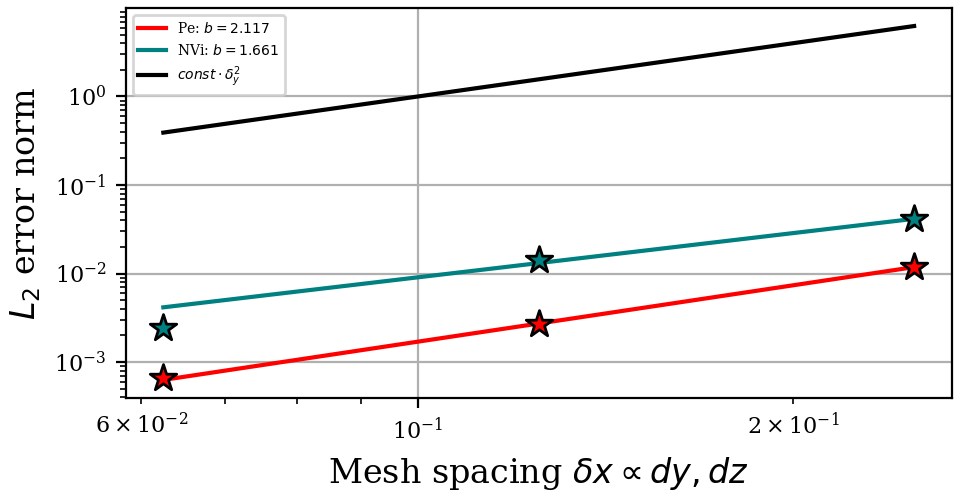

In [7]:
if (analyze)==True:
    boolfit=True
    colorlist=["red","Teal","darkorange","cyan","lime","magenta","blue","purple"]
    cols={}
    for i in range(len(vars)):
        cols[vars[i]]=colorlist[i]
    #cols[vars[0]]="Teal"
    #cols[vars[1]]="darkorange"
    #cols[vars[2]]="cyan"
    #cols[vars[3]]="lime"
    #cols[vars[4]]="magenta"
    #cols[vars[5]]="blue"
    %matplotlib notebook
    plt.close()
    fig,(ax) = plt.subplots(1,1,figsize=(4.8,2.5),layout="constrained")
    for var in vars:

        
        xplots=[]
        yplots=[]
        for key in L2:
            xplots.append(1.0/yspacings[key])
            yplots.append(L2s[var][key])
            ax.scatter(1.0/yspacings[key],L2s[var][key],color=cols[var],marker="*",s=100,edgecolor="black",zorder=10)
            #ax.scatter(1.0/yspacings[key],L2infs[var][key],color=cols[var],marker="^",s=100,edgecolor="black",zorder=10)
        if boolfit==True:
            popt_N=fitcofs[var]
            ax.plot(xfit,fitfunction(xfit, *popt_N),label=f'{var}: $b={popt_N[1]:.3f}$',color=cols[var])
        else:
            ax.plot(xplots,yplots,color=cols[var],label=f"{var}")
    
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.plot(xfit,1e2*xfit**2,color="black",label=r"$const \cdot \delta_y^2$")
    #ax.plot(xfit,1e2*xfit**4,color="black",label=r"$const \cdot \delta_y^4$",linestyle="dashed")
    ax.legend(fontsize=5)
    ax.set_xlabel(r"Mesh spacing $\delta x \propto dy,dz$")
    ax.set_ylabel(r"$L_2$ error norm")
    #ax.set_ylim(1e-5,1e-1)
    plt.show()

In [7]:
analyzemode="single"

idd=0
offset=2
grindfilename=gridfile_string(grids[idd][0],grids[idd][1],grids[idd][2],maindir)
df=xbout.open_boutdataset(datapath=f"{maindir}/data_{analyzemode}_{idd}/BOUT.dmp.nc",
                          gridfilepath=grindfilename,geometry="fci").isel(x=slice(offset,-offset))
grid = xr.open_dataset(grindfilename).isel(x=slice(offset,-offset))

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:                     (x: 36, y: 4, z: 32, t: 31)
Coordinates:
    dx                          (x, y, z) float64 dask.array<chunksize=(36, 4, 32), meta=np.ndarray>
    dy                          (x, y, z) float64 dask.array<chunksize=(36, 4, 32), meta=np.ndarray>
    dz                          (x, y, z) float64 dask.array<chunksize=(36, 4, 32), meta=np.ndarray>
  * t                           (t) float64 0.0 3.333 6.667 ... 96.67 100.0
    R                           (x, y, z) float64 0.9531 0.9531 ... 2.047 2.047
    Z                           (x, y, z) float64 -0.4844 -0.4531 ... 0.4844
  * x                           (x) int64 0 1 2 3 4 5 6 ... 29 30 31 32 33 34 35
  * y                           (y) float64 0.7854 2.356 3.927 5.498
  * z                           (z) float64 0.0 0.1963 0.3927 ... 5.89 6.087
Data variables: (12/166)
    Bxy                         (x, y, z) float64

<IPython.core.display.Javascript object>


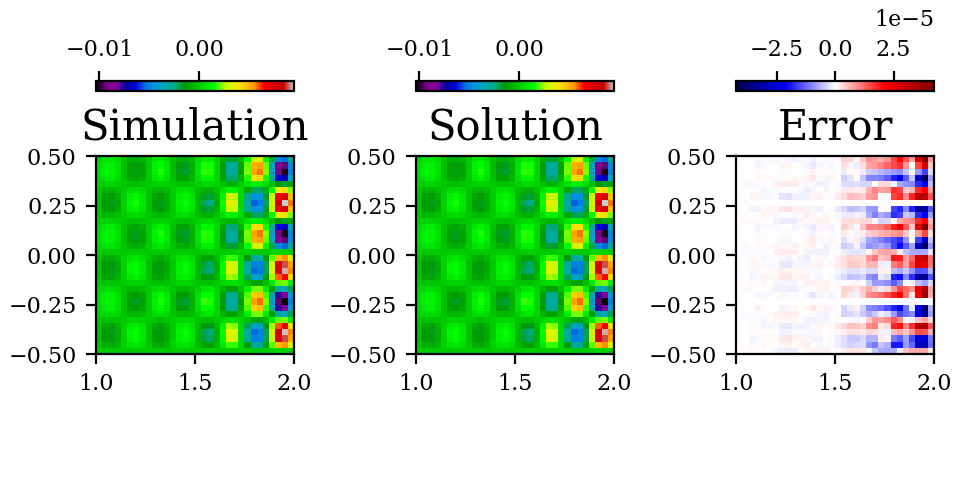

In [11]:
%matplotlib notebook
plt.close()
thist=10
thisy=0

Field="Vort"

#vmin=np.min(df_solution.isel(y=thisy,t=thist).values)
#vmax=np.max(df_solution.isel(y=thisy,t=thist).values)


fig,((ax1,ax2,ax3)) = plt.subplots(1,3,figsize=(4.8,1*2.4),layout="constrained")


try:
    df_solution=df[Field]-df["E_"+Field]
    vmin=np.min(df_solution.isel(y=thisy,t=thist).values)
    vmax=np.max(df_solution.isel(y=thisy,t=thist).values)
    b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
    plt.colorbar(b,location="top")
    vmine,vmaxe=calc_vmin_vmax(df["E_"+Field].isel(y=thisy,t=thist).values,0,True)
    c=ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["E_"+Field].isel(y=thisy,t=thist),
                     vmin=vmine,vmax=vmaxe,cmap="seismic")
    plt.colorbar(c,location="top")
    a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.set_aspect("equal")
    ax2.set_aspect("equal")
    ax3.set_aspect("equal")
except:
    a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),cmap="nipy_spectral")
plt.colorbar(a,location="top")
plt.show()

<IPython.core.display.Javascript object>


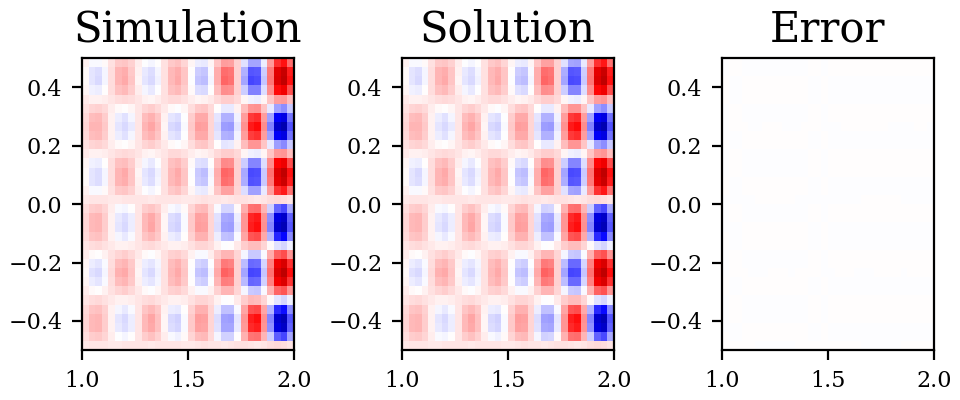

In [9]:
from matplotlib.animation import FuncAnimation
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(4.8,2.0),layout="constrained")
line, = ax1.plot([], [], lw=2)  # Create an empty line object to update during animation

thisy=0
# Define the initialization function
def init():
    line.set_data([], [])
    return line,

Field = "Vort"
df_solution=df[Field]-df["E_"+Field]
# Define the update function for each frame
def update(frame):
    ax1.cla()
    ax2.cla()
    ax3.cla()
    vmin=np.min(df_solution.isel(y=thisy).values)
    vmax=np.max(df_solution.isel(y=thisy).values)
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(df["E_"+Field]).isel(y=thisy,t=frame),vmin=-0.1,vmax=0.1,cmap="seismic")
    
    return line,

# Set up and run the animation
frames = (df["t"].size)  # Number of time steps
anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True,interval=100)
#anim.save("/u/toto/MMS_Braginskii/animation_modoperator.gif", writer="pillow", fps=10)
# Display the animation in the notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

In [ ]:
%matplotlib notebook
plt.close()

Field="Pe"
fig,(ax) = plt.subplots(1,1,figsize=(4.8,2),layout="constrained")
ax.plot(df.t,np.sqrt(((df[f"E_{Field}"])**2).mean(dim=("x","z","y"))),label="n")
ax_twin = ax.twinx()
ax_twin.plot(df.t,abs(df[f"E_{Field}"]).max(dim=("x","y","z")),color="red",linestyle="dotted")
ax.grid()
plt.show()

<IPython.core.display.Javascript object>


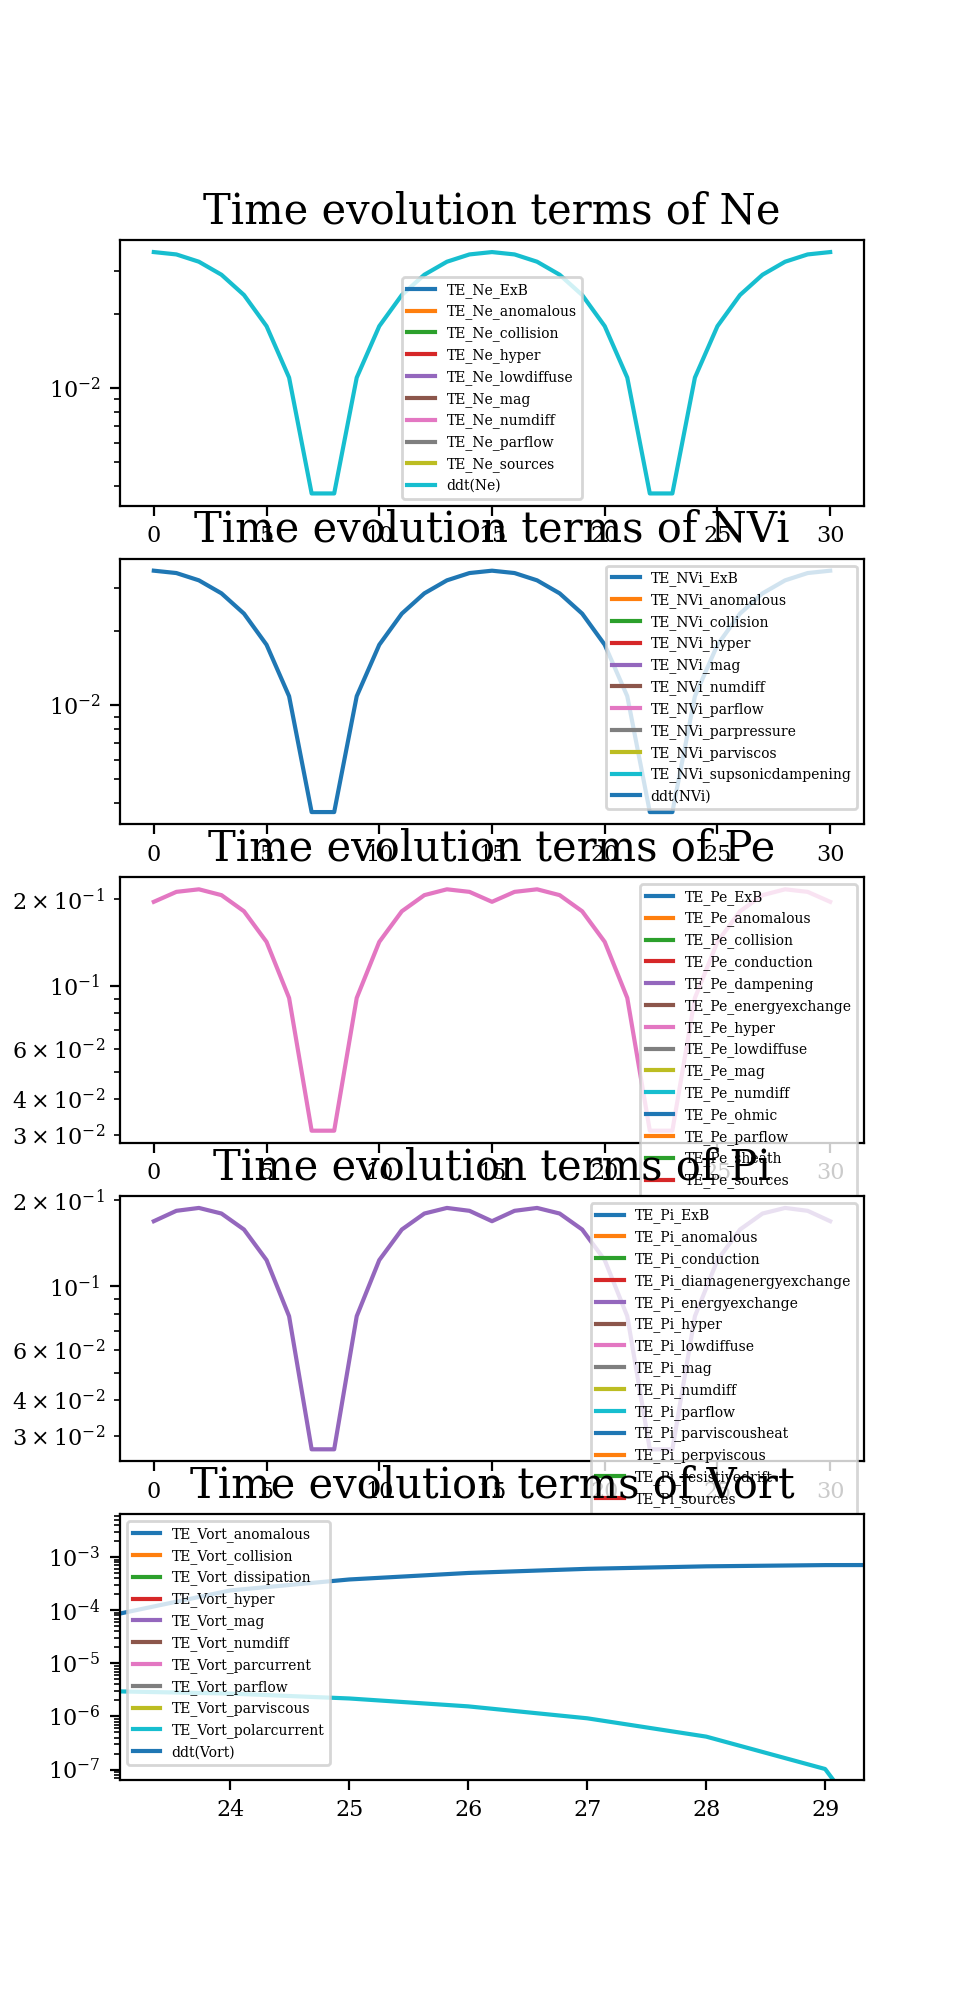

In [15]:
EvolvingVars=["Ne","NVi","Pe","Pi", "Vort"]


TE_EvolvingVars={}
found_vars=[]
for key in EvolvingVars:
    lookingfor=f"TE_{key}_"
    found = [key for key in df.data_vars if lookingfor in key]
    if found != None and len(found)>0:
        found_vars.append(key)
    TE_EvolvingVars[key]=found
plt.figure(figsize=(4.8,10))
counter = 1
for var in EvolvingVars:
    plt.subplot(len(EvolvingVars),1,counter)
    for key in TE_EvolvingVars[var]:
        plt.plot(abs(df[key]).max(dim=("x","y","z")),label=key)
    plt.plot(abs(df[f"ddt({var})"]).max(dim=("x","y","z")),label=f"ddt({var})")
    counter+=1
    plt.legend(fontsize=5)
    plt.yscale("log")
    plt.title("Time evolution terms of "+var)
    #plt.ylim(1e-5)

In [24]:
TE_EvolvingVars["Ne"]

['TE_Ne_ExB',
 'TE_Ne_anomalous',
 'TE_Ne_collision',
 'TE_Ne_hyper',
 'TE_Ne_mag',
 'TE_Ne_numdiff',
 'TE_Ne_parflow',
 'TE_Ne_sources']

<IPython.core.display.Javascript object>


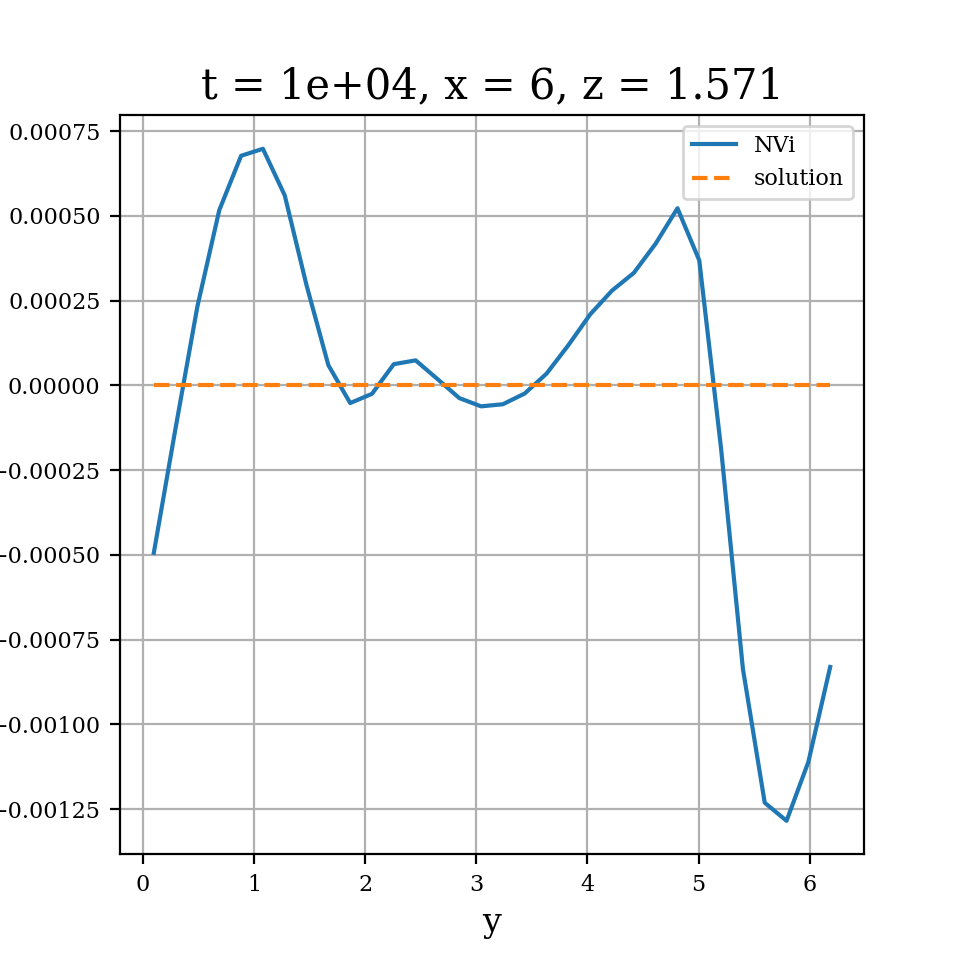

In [14]:
plt.figure()
thisx=4
thisz=2
thist=-1
Field = "NVi"
df_solution=df[Field]-df["E_"+Field]
soluton_Pe=df["Pe"]-df["E_"+"Pe"]
soluton_Ne=df["Ne"]-df["E_"+"Ne"]
df[Field].isel(t=thist,x=thisx,z=thisz).plot(label=f"{Field}")
#(soluton_Pe/soluton_Ne).isel(t=thist,x=thisx,z=thisz).plot(label=f"Te")
df_solution.isel(t=thist,x=thisx,z=thisz).plot(label=f"solution",linestyle="dashed")
plt.grid()
plt.legend()

In [1]:
plt.figure()
thisy=3
thisz=2
thist=1
Field = "Ne"
df_solution=df[Field]-df["E_"+Field]
soluton_Pe=df["Pe"]-df["E_"+"Pe"]
soluton_Ne=df["Ne"]-df["E_"+"Ne"]
df[Field].isel(z=thisz,y=thisy,t=thist).plot(label="simulation")
df_solution.isel(z=thisz,y=thisy,t=thist).plot(label="solution")
df["E_"+Field].isel(z=thisz,y=thisy,t=thist).plot(label="error")
#(soluton_Pe/soluton_Ne).isel(t=thist,y=thisy,z=thisz).plot(label=f"Te")
plt.legend()
plt.grid()

NameError: name 'plt' is not defined

In [2]:
plt.close("all")
%matplotlib inline
thisy=0
variables = [var for var in grid.data_vars if grid[var].shape == (grid.nx.values, grid.ny.values, grid.nz.values)]
for variable in variables:
    fig,ax=plt.subplots(figsize=(4.8,5),layout="constrained")
    kli=ax.pcolormesh(grid["R"].isel(y=thisy),grid["Z"].isel(y=thisy),grid[variable].isel(y=thisy))
    plt.colorbar(kli,label=variable)
    ax.set_aspect("equal")
    plt.show()

NameError: name 'plt' is not defined

In [3]:
plt.figure()
thisy=0
thisx=0
thist=4
Field = "Pi"
df_solution=df[Field]-df["E_"+Field]
#df[Field].isel(z=thisz,y=thisy,t=thist).plot(label="simulation")
#df_solution.isel(z=thisz,y=thisy,t=thist).plot(label="solution")
df["E_"+Field].isel(x=thisx,y=thisy,t=thist).plot(label="error")
plt.legend()
plt.grid()

NameError: name 'plt' is not defined

<IPython.core.display.Javascript object>


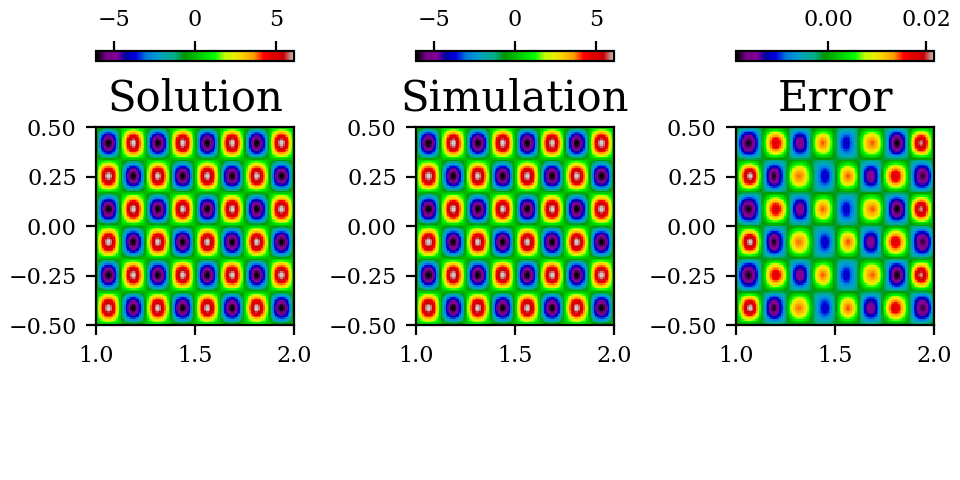

Text(0.5, 1.0, 'Error')

In [11]:
potfield="phi"
with open(f"solution_{potfield}.txt", "r") as file:
    equation_str = file.read().strip()
equation_psi = sp.sympify(equation_str)
xl = sp.Symbol('xl')
yl = sp.Symbol('yl')
zl = sp.Symbol('zl')
t = sp.Symbol("t")
solution_psi=np.zeros(df[potfield].values.shape)
equation_func = sp.lambdify((xl, yl, zl, t), equation_psi, "numpy")
t_values = df["t"].values
xl_values = df["xl"].values
yl_values = df["yl"].values
zl_values = df["zl"].values
solution_psi = equation_func(xl_values, yl_values, zl_values, t_values[:, None, None, None])
%matplotlib notebook
plt.close()
thist=10
thisy=0

Field=potfield

#vmin=np.min(df_solution.isel(y=thisy,t=thist).values)
#vmax=np.max(df_solution.isel(y=thisy,t=thist).values)


fig,((ax1,ax2,ax3)) = plt.subplots(1,3,figsize=(4.8,1*2.4),layout="constrained")
vmin=np.min(solution_psi[thist])
vmax=np.max(solution_psi[thist])
a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),solution_psi[thist,:,thisy,:],vmin=vmin,vmax=vmax,cmap="nipy_spectral")
plt.colorbar(a,location="top")
b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[potfield].isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
plt.colorbar(b,location="top")
c=ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(-solution_psi[thist,:,thisy,:]+df[potfield].isel(y=thisy,t=thist).values),cmap="nipy_spectral")
plt.colorbar(c,location="top")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax3.set_aspect("equal")
ax1.set_title("Solution")
ax2.set_title("Simulation")
ax3.set_title("Error")


In [5]:
plt.figure()
thisy=3
thisz=2
thist=1
plt.plot(df["xl"][:,thisy,thisz],solution_psi[thist,:,thisy,thisz],label="solution")
plt.plot(df["xl"][:,thisy,thisz],df[potfield][thist,:,thisy,thisz],label="simulation")
plt.plot(df["xl"][:,thisy,thisz],df["debug_phibndry3d"][thist,:,thisy,thisz],label="bndry")
plt.legend()
plt.grid()

NameError: name 'plt' is not defined

In [8]:
df["xl"].isel(y=0,z=0).values

array([-0.046875, -0.015625,  0.015625,  0.046875,  0.078125,  0.109375,
        0.140625,  0.171875,  0.203125,  0.234375,  0.265625,  0.296875,
        0.328125,  0.359375,  0.390625,  0.421875,  0.453125,  0.484375,
        0.515625,  0.546875,  0.578125,  0.609375,  0.640625,  0.671875,
        0.703125,  0.734375,  0.765625,  0.796875,  0.828125,  0.859375,
        0.890625,  0.921875,  0.953125,  0.984375,  1.015625,  1.046875])

In [27]:
(68-3+0.5) / (68 - 2*2)

1.0234375

In [15]:
df["yl"].isel(y=0).values

array([[0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816],
       [0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816],
       [0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816],
       ...,
       [0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816],
       [0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816],
       [0.78539816, 0.78539816, 0.78539816, ..., 0.78539816, 0.78539816,
        0.78539816]])

In [40]:
L2s["Vort"]

{'0': array(0.00100211), '1': array(0.00020366), '2': array(5.30061728e-05)}

In [45]:
yspacings

{'0': 64, '1': 128, '2': 256}

In [11]:
df.G1.values

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [10]:
df["TE_Vort_collision"].values

array([[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.000000